# EDA and Pipeline setup

### Data loading and Graph Setup

In [ ]:
import os
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sec_benign = '#2ca02c'  # Green for Normal
sec_attack = '#d62728'  # Red for Attack
sec_black = '#282828'
sec_dark_gray = '#606060'

sns.set_theme(style="white", font_scale=1.1)

def apply_custom_formatting(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=18, fontweight='bold', color=sec_black, pad=15)
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color=sec_black, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color=sec_black, labelpad=10)
    ax.tick_params(colors=sec_black, labelsize=12)
    ax.spines['bottom'].set_color(sec_dark_gray)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color(sec_dark_gray)
    ax.spines['left'].set_linewidth(2)
    sns.despine(top=True, right=True, left=False, bottom=False)
    

ecu_df = pl.read_parquet(os.path.join("data", "cleaned_ecu.parquet"))

wustl_df = pl.read_parquet(os.path.join("data", "cleaned_wustl.parquet"))
    

print(f"ECU DataFrame Shape: {ecu_df.shape}")
# ecu_df.head()

print(f"WUSTL DataFrame Shape: {wustl_df.shape}")
# wustl_df.head()

ECU DataFrame Shape: (111207, 6)
WUSTL DataFrame Shape: (16318, 43)


### ECU EDA

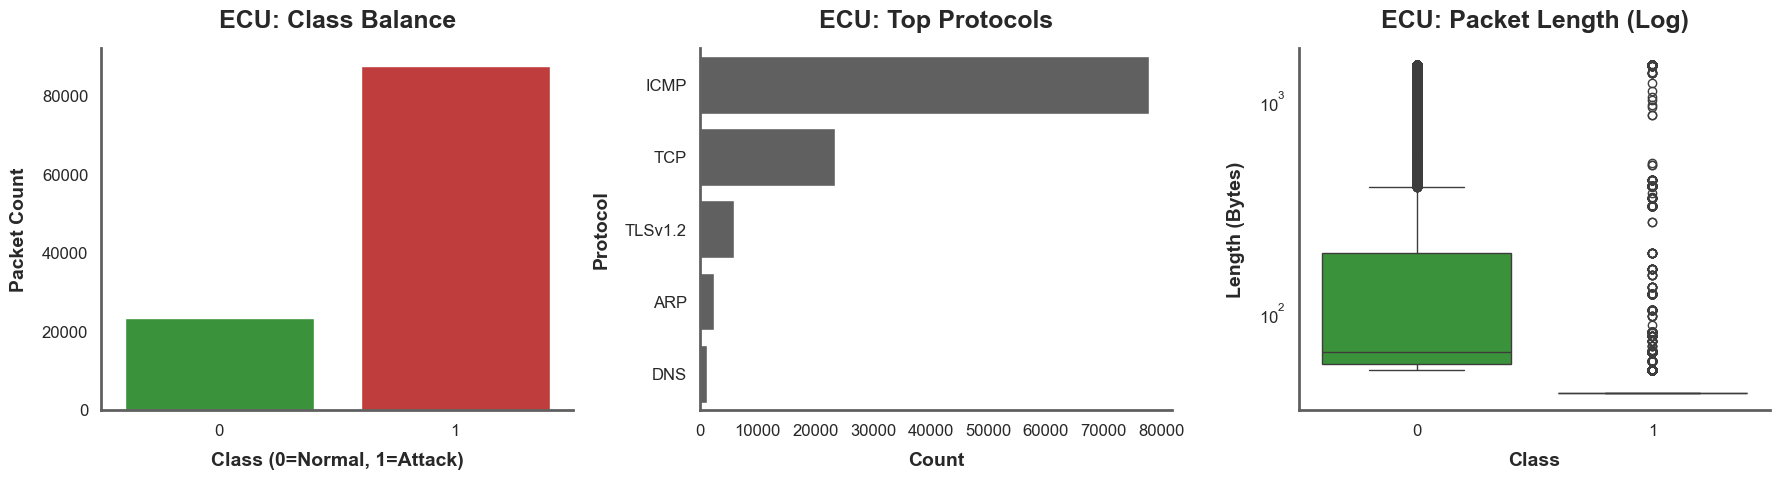

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class Balance
ecu_counts = ecu_df["label"].value_counts().to_pandas().sort_values("label")
sns.barplot(x="label", y="count", data=ecu_counts, 
            hue="label", palette=[sec_benign, sec_attack], legend=False, ax=axes[0])
apply_custom_formatting(axes[0], "ECU: Class Balance", "Class (0=Normal, 1=Attack)", "Packet Count")

# Top Protocols
ecu_protos = ecu_df["Protocol"].value_counts().sort("count", descending=True).head(5).to_pandas()
sns.barplot(x="count", y="Protocol", data=ecu_protos, color=sec_dark_gray, ax=axes[1])
apply_custom_formatting(axes[1], "ECU: Top Protocols", "Count", "Protocol")

# Packet Length by Class (Log Scale)
ecu_len_pd = ecu_df.select(["label", "Length"]).to_pandas()
sns.boxplot(x="label", y="Length", data=ecu_len_pd, 
            hue="label", palette=[sec_benign, sec_attack], legend=False, ax=axes[2])
axes[2].set_yscale("log")
apply_custom_formatting(axes[2], "ECU: Packet Length (Log)", "Class", "Length (Bytes)")

plt.tight_layout()
plt.show()

In [9]:
pl.read_excel(
    os.path.join("data", "ECU_IoHT.xlsx")
)["Type of attack"].value_counts(sort=True)

Type of attack,count
str,u32
"""Smurf Attack""",77920
"""No Attack""",23453
"""Nmap Port Scan""",6836
"""ARP Spoofing""",2359
"""DoS Attack""",639


### WUSTL EDA
 

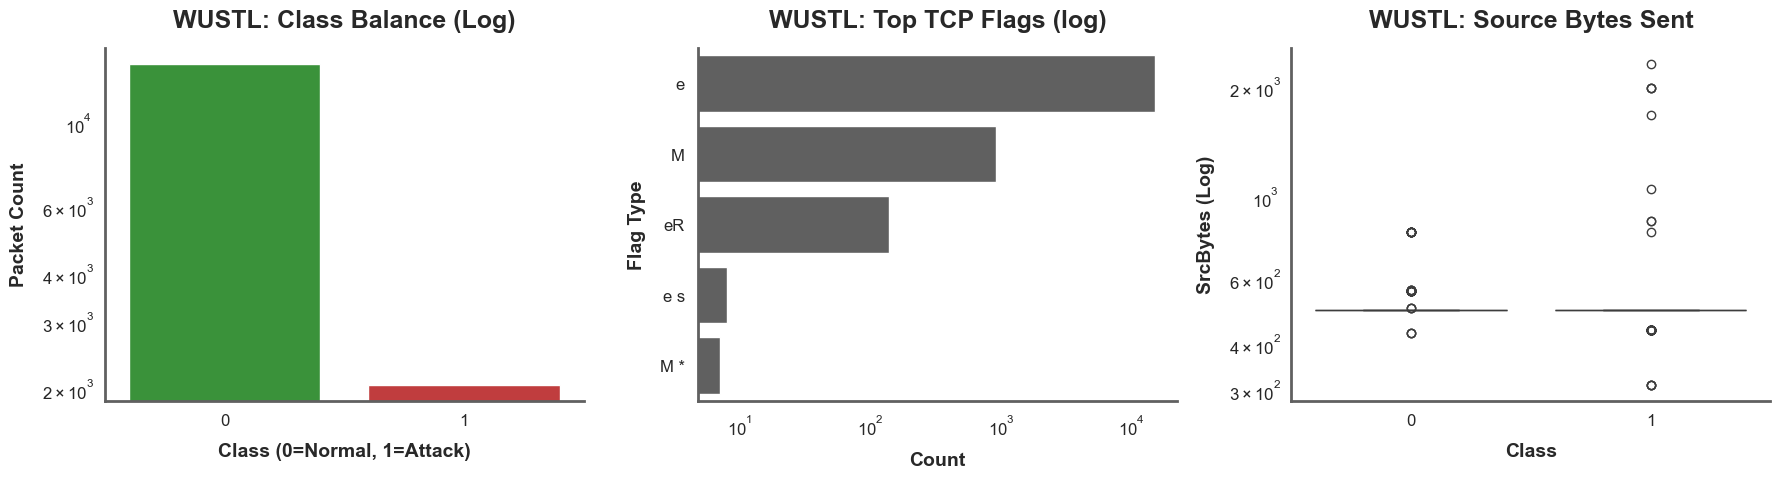

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class Balance
wustl_counts = wustl_df["label"].value_counts().to_pandas().sort_values("label")
sns.barplot(x="label", y="count", data=wustl_counts, 
            hue="label", palette=[sec_benign, sec_attack], legend=False, ax=axes[0])
axes[0].set_yscale("log")
apply_custom_formatting(axes[0], "WUSTL: Class Balance (Log)", "Class (0=Normal, 1=Attack)", "Packet Count")

# Top TCP Flags
wustl_flags = wustl_df["Flgs"].value_counts().sort("count", descending=True).head(5).to_pandas()
axes[1].set_xscale("log")
sns.barplot(x="count", y="Flgs", data=wustl_flags, color=sec_dark_gray, ax=axes[1])
apply_custom_formatting(axes[1], "WUSTL: Top TCP Flags (log)", "Count", "Flag Type")

# Source Bytes by Class (Log Scale)
wustl_bytes_pd = wustl_df.select(["label", "SrcBytes"]).to_pandas()
sns.boxplot(x="label", y="SrcBytes", data=wustl_bytes_pd, 
            hue="label", palette=[sec_benign, sec_attack], legend=False, ax=axes[2])
axes[2].set_yscale("log")
apply_custom_formatting(axes[2], "WUSTL: Source Bytes Sent", "Class", "SrcBytes (Log)")

plt.tight_layout()
plt.show()

In [12]:
pl.read_csv(
    os.path.join("data", "wustl-ehms-2020_with_attacks_categories.csv"),
    columns=["Attack Category"]
)["Attack Category"].value_counts(sort=True)

Attack Category,count
str,u32
"""normal""",14272
"""Spoofing""",1124
"""Data Alteration""",922
